In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customer_shopping_behavior.csv")




In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [6]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [7]:
df["Review Rating"].unique()

array([3.1, 3.5, 2.7, 2.9, 3.2, 2.6, 4.8, 4.1, 4.9, 4.5, 4.7, 2.8, 4.6,
       3.3, 4.4, 3.6, 5. , 4. , nan, 4.2, 3.7, 3.9, 3. , 3.8, 3.4, 4.3,
       2.5])

In [8]:
print("Mean:", df["Review Rating"].mean())
print("Median:", df["Review Rating"].median())

Mean: 3.750064716541548
Median: 3.8


In [9]:
# Missing Data Handling

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [10]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [11]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [12]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [13]:
# create a new column age_group

labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [14]:
df[['age',"age_group"]].head()

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged


In [15]:
# creating new coloumn purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90

}

df["purchase_frequency_days"] = df["frequency_of_purchases"].map(frequency_mapping)

In [16]:
df[["frequency_of_purchases","purchase_frequency_days"]].tail()

,frequency_of_purchases,purchase_frequency_days
3895,Weekly,7
3896,Bi-Weekly,14
3897,Quarterly,90
3898,Weekly,7
3899,Quarterly,90


In [17]:
df[["discount_applied", "promo_code_used"]].head()

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes


In [18]:
(df["discount_applied"] == df["promo_code_used"]).all()

np.True_

In [19]:
df = df.drop("promo_code_used", axis =1)

In [20]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='str')

In [21]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365


### DATA ANALYSIS

### Top 5 Products by Review Rating

In [22]:
top_5_products = print("Top 5 Products by Review Rating:",df.groupby("item_purchased")["review_rating"].mean().sort_values(ascending=False).head(5))

Top 5 Products by Review Rating: item_purchased
Gloves     3.861429
Sandals    3.844375
Boots      3.818750
Hat        3.801299
Skirt      3.784810
Name: review_rating, dtype: float64


### Revenue by Gender

In [23]:
revenue_by_gender = print("Revenue by",df.groupby("gender")["purchase_amount"].sum())

Revenue by gender
Female     75191
Male      157890
Name: purchase_amount, dtype: int64


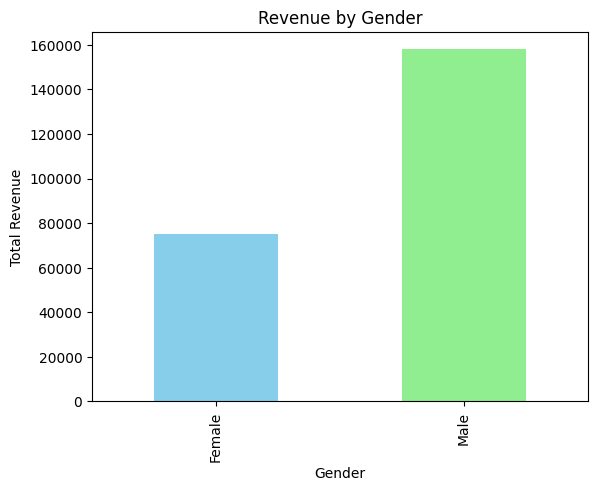

In [24]:
revenue_by_gender = df.groupby("gender")["purchase_amount"].sum()

revenue_by_gender.plot(kind="bar", color=["skyblue", "lightgreen"])
plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.show()


### Gender By Age Group

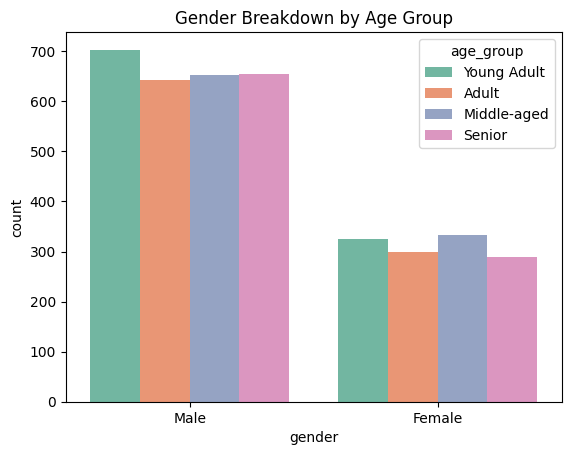

In [25]:
sns.countplot(data=df, x="gender", hue="age_group", palette="Set2")
plt.title("Gender Breakdown by Age Group")
plt.show()

In [26]:

count = df["category"].value_counts()
count

category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

### Distribution by product categories

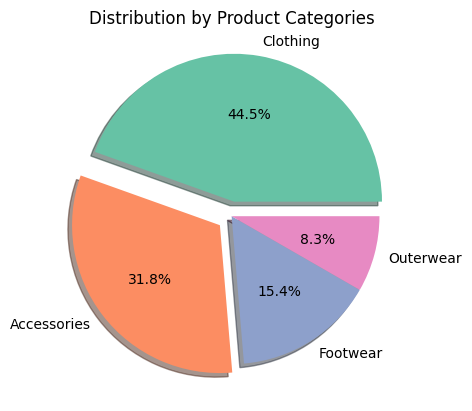

In [27]:
plt.pie(count, labels = count.index, autopct='%1.1f%%', explode = [0.1,0.1,0,0],colors = sns.color_palette("Set2") ,shadow = True) 
plt.title("Distribution by Product Categories")
plt.show()

### Top item purchased

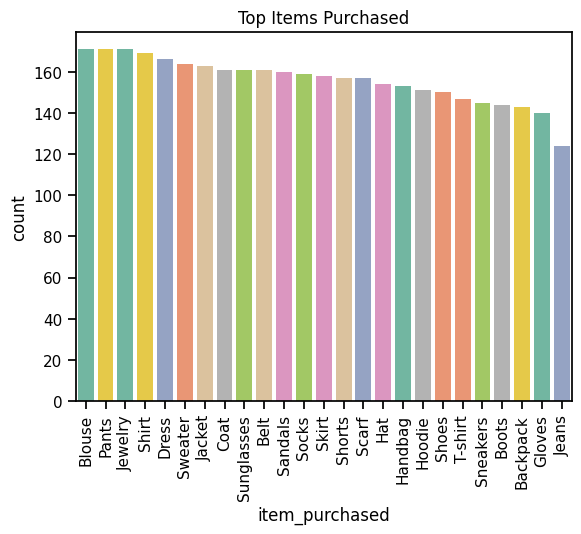

In [28]:
sns.set_context("notebook")

sns.countplot(data=df, x="item_purchased", order=df["item_purchased"].value_counts().index,
palette="Set2", hue = "item_purchased", legend= False)
plt.title("Top Items Purchased")
plt.xticks(rotation=90)
plt.show()


### Season purchase trends

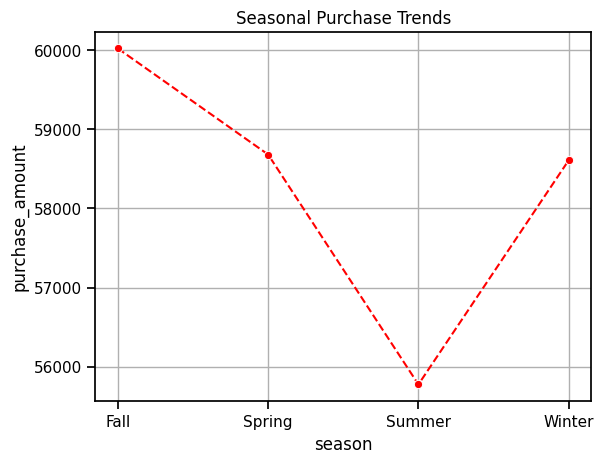

In [29]:


seasonal_trends = df.groupby("season")["purchase_amount"].sum().reset_index()

sns.lineplot(data=seasonal_trends, x="season", y="purchase_amount", marker="o" , linestyle="--", color="red")
plt.title("Seasonal Purchase Trends")
plt.grid()
plt.show()



### Subscription status pie chart

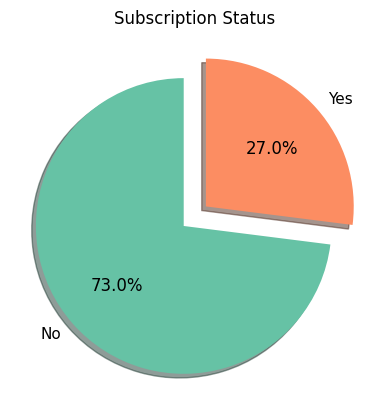

In [30]:


df["subscription_status"].value_counts().plot.pie(
    autopct="%1.1f%%", explode = [0.1,0.1], shadow = True, colors = sns.color_palette("Set2"),startangle=90
)
plt.title("Subscription Status")
plt.show()


### correlation between Age Group and Category

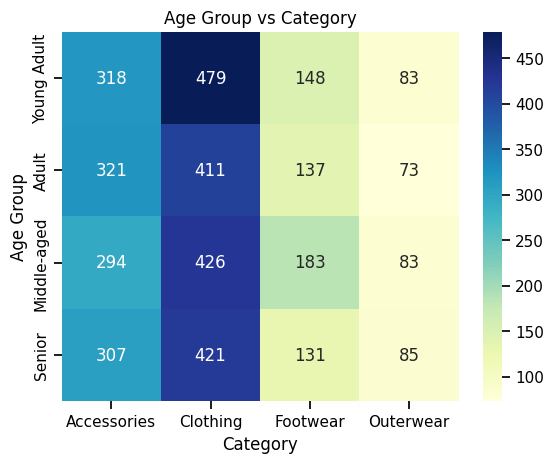

In [31]:
sns.set_context("notebook")

# Create cross-tab of age_group vs category
age_cat_ct = pd.crosstab(df["age_group"], df["category"])

# Plot heatmap
sns.heatmap(age_cat_ct, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Age Group vs Category")
plt.xlabel("Category")
plt.ylabel("Age Group")
plt.show()


In [32]:
pip install mysql-connector-python pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
pip install pymysql sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "passward786"
host = "localhost"
port = "3306"
database = "customer_behavior"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "customer"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM customer LIMIT 5;", engine)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365


In [35]:
import mysql.connector

config = {
    'host': 'localhost',
    'user': 'root',
    'password': 'passward786',
    'database': 'customer_behavior'
}

try:
    conn = mysql.connector.connect(**config)
    print("Connection successful!")
    
    # Test query: List all tables first
    df_tables = pd.read_sql_query("SHOW TABLES;", conn)
    print("Tables in database:")
    print(df_tables)
    
    # Replace 'your_table' with actual table, e.g., first table name
    # df = pd.read_sql_query("SELECT * FROM actual_table_name LIMIT 5", conn)
    # print(df)
    
except mysql.connector.Error as err:
    print(f"Error: {err}")
finally:
    if 'conn' in locals() and conn.is_connected():
        conn.close()

Connection successful!
Tables in database:
  Tables_in_customer_behavior
0                    customer


C:\Users\syedi\AppData\Local\Temp\ipykernel_22464\3921976499.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql_query("SHOW TABLES;", conn)
